# DemandCast: Initial Exploration of January 2025 Yellow Taxi Data

## Objective
This notebook performs a focused initial exploration of NYC Yellow Taxi trip data to support the DemandCast task:

**Predict hourly taxi demand by pickup zone (`PULocationID`).**

The raw file is trip-level. For forecasting, the modeling data will likely be aggregated to zone-hour rows such as:
- `pickup_hour`
- `PULocationID`
- `trip_count`


## 1) Load Data
We load the January 2025 Yellow Taxi parquet file from `../data/` and keep this section minimal and explicit.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_columns', 50)


In [2]:
DATA_PATH = Path('../data/yellow_tripdata_2025-01.parquet')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Expected file not found: {DATA_PATH}')

df_raw = pd.read_parquet(DATA_PATH)
print('Loaded:', DATA_PATH)
print('Raw shape:', df_raw.shape)


Loaded: ../data/yellow_tripdata_2025-01.parquet
Raw shape: (3475226, 20)


## 2) Dataset Shape, Columns, and First Look

In [3]:
print('Shape:', df_raw.shape)
print()
print('Columns:')
for c in df_raw.columns:
    print('-', c)

print()
print('Dtypes:')
display(df_raw.dtypes)

display(df_raw.head())


Shape: (3475226, 20)

Columns:
- VendorID
- tpep_pickup_datetime
- tpep_dropoff_datetime
- passenger_count
- trip_distance
- RatecodeID
- store_and_fwd_flag
- PULocationID
- DOLocationID
- payment_type
- fare_amount
- extra
- mta_tax
- tip_amount
- tolls_amount
- improvement_surcharge
- total_amount
- congestion_surcharge
- Airport_fee
- cbd_congestion_fee

Dtypes:


VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


## 3) Column Meaning and Initial Interpretation
Major fields used in this dataset (aligned to the Yellow Taxi data dictionary):

- `tpep_pickup_datetime`: date/time when the meter was engaged (trip start).
- `tpep_dropoff_datetime`: date/time when the meter was disengaged (trip end).
- `PULocationID`: TLC taxi zone where the meter was engaged (pickup zone).
- `DOLocationID`: TLC taxi zone where the meter was disengaged (dropoff zone).
- `passenger_count`: number of passengers reported for the trip.
- `trip_distance`: elapsed trip distance in miles reported by the meter.
- `RatecodeID`: final rate code at trip end (for example `1=Standard`, `2=JFK`, `3=Newark`, `5=Negotiated`, `6=Group ride`, `99=Null/unknown`).
- `store_and_fwd_flag`: whether the trip record was buffered in-vehicle before transmission (`Y`/`N`).
- `payment_type`: coded payment method (`0=Flex Fare`, `1=Credit card`, `2=Cash`, `3=No charge`, `4=Dispute`, `5=Unknown`, `6=Voided`).
- Fare fields (`fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, `congestion_surcharge`, `Airport_fee`, `cbd_congestion_fee`) are trip outcomes; `total_amount` excludes cash tips.
- `Airport_fee`: pickup-only fee at LGA/JFK; `cbd_congestion_fee`: per-trip charge associated with congestion pricing (effective January 2025).

For DemandCast, pickup time and pickup zone are central predictors. Many fare/payment/dropoff fields are outcomes of completed trips and should be treated carefully to avoid leakage when forecasting future demand.


## 4) Data Quality Checks
These checks are run on the raw file to identify issues that can bias later demand features (for example, bad timestamps or impossible values). We keep this section practical and focused on checks that matter for zone-hour forecasting.


In [4]:
# Null counts and percentages
null_counts = df_raw.isna().sum()
null_pct = (null_counts / len(df_raw) * 100).round(2)
null_summary = (
    pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
    .sort_values('null_count', ascending=False)
)
display(null_summary)

# Duplicate rows
duplicate_count = int(df_raw.duplicated().sum())
print('Duplicate row count:', duplicate_count)

# Pickup/dropoff datetime sanity
pickup_after_dropoff = int((df_raw['tpep_pickup_datetime'] > df_raw['tpep_dropoff_datetime']).sum())
print('Rows with pickup after dropoff:', pickup_after_dropoff)

# Trip duration (minutes) creation + inspection
df_raw['trip_duration_min'] = (
    (df_raw['tpep_dropoff_datetime'] - df_raw['tpep_pickup_datetime']).dt.total_seconds() / 60
)
nonpositive_duration = int((df_raw['trip_duration_min'] <= 0).sum())
print('Rows with zero/negative trip duration:', nonpositive_duration)
display(df_raw['trip_duration_min'].describe(percentiles=[0.01, 0.5, 0.99]))

# Trip distance sanity + inspection
nonpositive_distance = int((df_raw['trip_distance'] <= 0).sum())
print('Rows with zero/negative trip distance:', nonpositive_distance)
display(df_raw['trip_distance'].describe(percentiles=[0.01, 0.5, 0.99]))

# Suspicious passenger counts
passenger_counts = df_raw['passenger_count'].value_counts(dropna=False).sort_index()
display(passenger_counts.head(10))
print('Rows with passenger_count > 6:', int((df_raw['passenger_count'] > 6).sum()))
print('Rows with passenger_count < 0:', int((df_raw['passenger_count'] < 0).sum()))

# Selected fare/total sanity checks
fare_cols = ['fare_amount', 'tip_amount', 'total_amount']
fare_checks = pd.DataFrame(
    {
        'negative_count': [int((df_raw[c] < 0).sum()) for c in fare_cols],
        'zero_count': [int((df_raw[c] == 0).sum()) for c in fare_cols],
    },
    index=fare_cols,
)
display(fare_checks)

# Pickup zone validity checks
invalid_pu = int((df_raw['PULocationID'] <= 0).sum())
missing_pu = int(df_raw['PULocationID'].isna().sum())
print('Invalid PULocationID (<=0):', invalid_pu)
print('Missing PULocationID:', missing_pu)


,null_count,null_pct
Airport_fee,540149,15.54
passenger_count,540149,15.54
congestion_surcharge,540149,15.54
RatecodeID,540149,15.54
store_and_fwd_flag,540149,15.54
VendorID,0,0.00
mta_tax,0,0.00
total_amount,0,0.00
improvement_surcharge,0,0.00
tolls_amount,0,0.00


Duplicate row count: 0
Rows with pickup after dropoff: 124
Rows with zero/negative trip duration: 2051


count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
1%       6.666667e-01
50%      1.170000e+01
99%      5.891667e+01
max      5.626317e+03
Name: trip_duration_min, dtype: float64

Rows with zero/negative trip distance: 90893


count    3.475226e+06
mean     5.855126e+00
std      5.646016e+02
min      0.000000e+00
1%       0.000000e+00
50%      1.670000e+00
99%      1.950000e+01
max      2.764236e+05
Name: trip_distance, dtype: float64

passenger_count
0.0      24656
1.0    2322434
2.0     407761
3.0      91409
4.0      59009
5.0      17786
6.0      12004
7.0          4
8.0         11
9.0          3
Name: count, dtype: int64

Rows with passenger_count > 6: 18
Rows with passenger_count < 0: 0


,negative_count,zero_count
fare_amount,144118,1398
tip_amount,124,1118008
total_amount,63037,559


Invalid PULocationID (<=0): 0
Missing PULocationID: 0


### Demand-Focused Subset (January 2025 Only)
The raw file includes a small number of pickups outside January 2025. We keep raw-file quality checks above, then create a January-only subset for demand-pattern analysis and zone-hour aggregation.

In [5]:
jan_start = pd.Timestamp('2025-01-01')
jan_end = pd.Timestamp('2025-02-01')

pickup_min = df_raw['tpep_pickup_datetime'].min()
pickup_max = df_raw['tpep_pickup_datetime'].max()

df_jan = df_raw[
    (df_raw['tpep_pickup_datetime'] >= jan_start)
    & (df_raw['tpep_pickup_datetime'] < jan_end)
].copy()

print('Raw pickup range:', pickup_min, 'to', pickup_max)
print('Raw rows:', len(df_raw))
print('January-only rows:', len(df_jan))
print('Rows excluded outside Jan 2025:', len(df_raw) - len(df_jan))


Raw pickup range: 2024-12-31 20:47:55 to 2025-02-01 00:00:44
Raw rows: 3475226
January-only rows: 3475204
Rows excluded outside Jan 2025: 22


## 5) Basic Descriptive Summaries
These summaries stay lightweight and focused on variables relevant to trip quality and demand context.

In [6]:
summary_cols = [
    'passenger_count',
    'trip_distance',
    'trip_duration_min',
    'fare_amount',
    'tip_amount',
    'total_amount',
]

display(df_jan[summary_cols].describe().T)

print('Payment type distribution (top):')
display(df_jan['payment_type'].value_counts(dropna=False).head(10))

print('Store-and-forward flag distribution:')
display(df_jan['store_and_fwd_flag'].value_counts(dropna=False))

print('Vendor distribution:')
display(df_jan['VendorID'].value_counts(dropna=False))


,count,mean,std,min,25%,50%,75%,max
passenger_count,2935055.0,1.297855,0.750741,0.000000,1.000000,1.00,1.000000,9.000000
trip_distance,3475204.0,5.855141,564.603387,0.000000,0.980000,1.67,3.100000,276423.570000
trip_duration_min,3475204.0,15.018108,38.713674,-51472.316667,7.283333,11.70,18.333333,5626.316667
fare_amount,3475204.0,17.081793,463.474383,-900.000000,8.600000,12.11,19.500000,863372.120000
tip_amount,3475204.0,2.959804,3.779674,-86.000000,0.000000,2.45,3.930000,400.000000
total_amount,3475204.0,25.611278,463.659943,-901.000000,15.200000,19.95,27.780000,863380.370000


Payment type distribution (top):


payment_type
1    2444377
0     540149
2     390423
4      76481
3      23773
5          1
Name: count, dtype: int64

Store-and-forward flag distribution:


store_and_fwd_flag
N       2927409
None     540149
Y          7646
Name: count, dtype: int64

Vendor distribution:


VendorID
2    2719838
1     753671
7       1206
6        489
Name: count, dtype: int64

## 6) Time-Based Demand Exploration
The goal here is to identify temporal patterns tied to hourly demand forecasting by pickup zone.

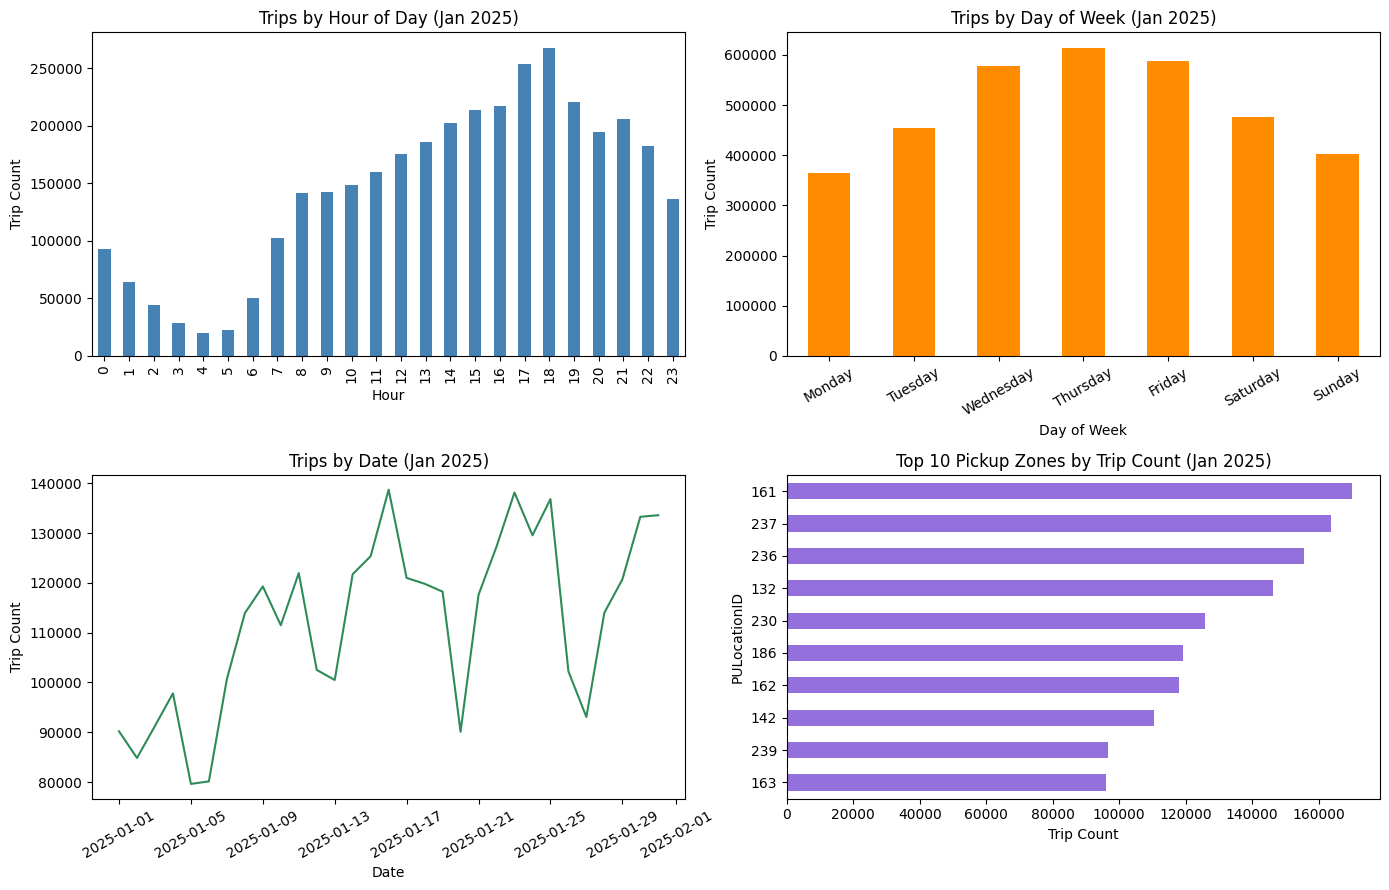

In [7]:
# Time-derived features for demand analysis
ordered_day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_jan['pickup_hour'] = df_jan['tpep_pickup_datetime'].dt.floor('h')
df_jan['pickup_hour_of_day'] = df_jan['tpep_pickup_datetime'].dt.hour
df_jan['pickup_dow'] = df_jan['tpep_pickup_datetime'].dt.dayofweek
df_jan['pickup_day_name'] = pd.Categorical(
    df_jan['tpep_pickup_datetime'].dt.day_name(),
    categories=ordered_day_names,
    ordered=True,
)
df_jan['pickup_date'] = df_jan['tpep_pickup_datetime'].dt.date

trips_by_hour = df_jan.groupby('pickup_hour_of_day').size()
trips_by_day = df_jan.groupby('pickup_day_name', observed=True).size()
trips_by_date = df_jan.groupby('pickup_date').size()
top_pickup_zones = df_jan['PULocationID'].value_counts().head(10)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

trips_by_hour.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Trips by Hour of Day (Jan 2025)')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Trip Count')

trips_by_day.plot(kind='bar', ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Trips by Day of Week (Jan 2025)')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Trip Count')
axes[0, 1].tick_params(axis='x', rotation=30)

trips_by_date.plot(ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Trips by Date (Jan 2025)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Trip Count')
axes[1, 0].tick_params(axis='x', rotation=30)

(top_pickup_zones.sort_values(ascending=True)
 .plot(kind='barh', ax=axes[1, 1], color='mediumpurple'))
axes[1, 1].set_title('Top 10 Pickup Zones by Trip Count (Jan 2025)')
axes[1, 1].set_xlabel('Trip Count')
axes[1, 1].set_ylabel('PULocationID')

plt.tight_layout()
plt.show()


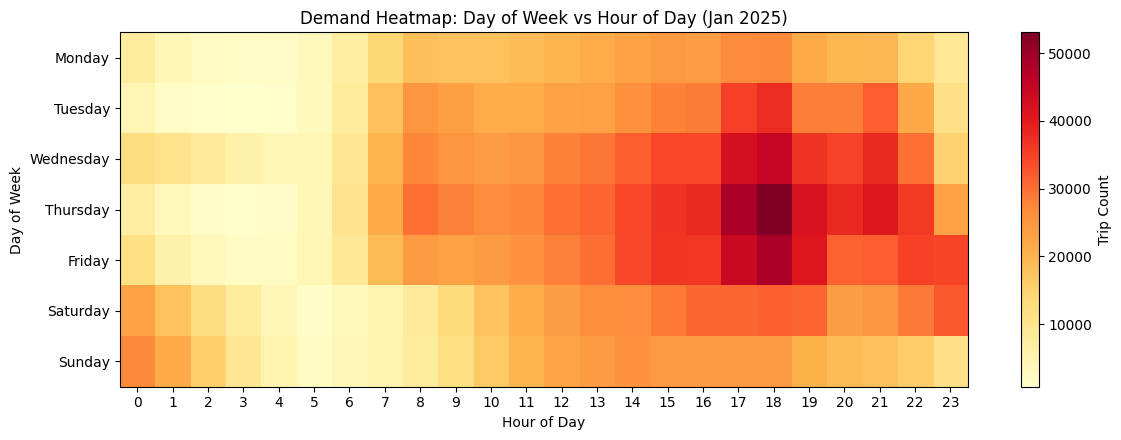

In [8]:
# Hour-of-day vs day-of-week heatmap (trip counts)
heatmap_counts = (
    df_jan.groupby(['pickup_dow', 'pickup_hour_of_day'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(heatmap_counts.values, aspect='auto', cmap='YlOrRd')

ax.set_title('Demand Heatmap: Day of Week vs Hour of Day (Jan 2025)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_xticks(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(ordered_day_names)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Trip Count')

plt.tight_layout()
plt.show()


## 7) Pickup Zone Demand Aggregation Preview
This converts trip-level records into the likely modeling grain: one row per (`pickup_hour`, `PULocationID`) with `trip_count`.

In [9]:
demand_hourly_zone = (
    df_jan.groupby(['pickup_hour', 'PULocationID'], as_index=False)
    .size()
    .rename(columns={'size': 'trip_count'})
)

print('Aggregated table shape:', demand_hourly_zone.shape)
display(demand_hourly_zone.head())

print('trip_count summary:')
display(demand_hourly_zone['trip_count'].describe())

top_zones_agg = (
    demand_hourly_zone.groupby('PULocationID', as_index=False)['trip_count']
    .sum()
    .sort_values('trip_count', ascending=False)
    .head(10)
)

top_hours_agg = (
    demand_hourly_zone.groupby('pickup_hour', as_index=False)['trip_count']
    .sum()
    .sort_values('trip_count', ascending=False)
    .head(10)
)

print('Highest-demand pickup zones (aggregated):')
display(top_zones_agg)

print('Highest-demand pickup hours (aggregated):')
display(top_hours_agg)


Aggregated table shape: (97014, 3)


,pickup_hour,PULocationID,trip_count
0,2025-01-01,4,28
1,2025-01-01,7,12
2,2025-01-01,9,1
3,2025-01-01,10,1
4,2025-01-01,12,1


trip_count summary:


count    97014.000000
mean        35.821675
std         74.808488
min          1.000000
25%          1.000000
50%          4.000000
75%         28.000000
max        950.000000
Name: trip_count, dtype: float64

Highest-demand pickup zones (aggregated):


,PULocationID,trip_count
156,161,169977
232,237,163703
231,236,155647
127,132,146135
225,230,125829
181,186,119130
157,162,117930
137,142,110584
234,239,96614
158,163,95905


Highest-demand pickup hours (aggregated):


,pickup_hour,trip_count
378,2025-01-16 18:00:00,13288
546,2025-01-23 18:00:00,12287
738,2025-01-31 18:00:00,11874
377,2025-01-16 17:00:00,11577
714,2025-01-30 18:00:00,11557
737,2025-01-31 17:00:00,11173
545,2025-01-23 17:00:00,11122
570,2025-01-24 18:00:00,11066
522,2025-01-22 18:00:00,10798
379,2025-01-16 19:00:00,10343


## 8) Likely Useful Features for Demand Prediction
Likely useful predictors for forecasting future hourly demand by pickup zone:

- Pickup-time features known before the prediction window (hour of day, day of week, weekday/weekend).
- `PULocationID` (zone identity).
- Historical lag features derived from past aggregated demand (`trip_count` by zone-hour).

Lower-priority or leakage-prone as direct predictors for future demand:

- Trip outcome fields such as `trip_distance`, `fare_amount`, `tip_amount`, `total_amount`.
- Dropoff outcomes such as `DOLocationID` and realized dropoff timing.
- Payment details that are typically known after trip completion.

Key forecasting rule: favor variables available at prediction time, and avoid post-trip outcome variables that leak information from the future target window.


## 9) Key Findings and Next Steps
### Key findings
- The dataset has a stable schema with several fields containing meaningful missingness that should be handled explicitly later.
- A small set of temporal and numeric anomalies exists (for example, pickup-after-dropoff and non-positive duration/distance rows).
- Demand shows clear hour-of-day and day-of-week structure, with concentrated activity in a subset of pickup zones.
- The modeling unit should be zone-hour demand: (`pickup_hour`, `PULocationID`) -> `trip_count`.

### Next steps
- Finalize practical cleaning rules for timestamp/value anomalies.
- Engineer time and lag features from the zone-hour aggregated table.
- Use temporal train/validation/test splits for later forecasting models.
